# RPG Graph Analysis: Cross-Dataset Comparison

This notebook compares the completed graph-analysis outputs for all four paper datasets: Sports, Beauty, Toys, and CDs. Dataset-specific interpretation still belongs in the individual notebooks; this file is for compact side-by-side checks.


In [1]:
from pathlib import Path
import json
import os
import tempfile

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'rpg-matplotlib'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != 'RPG' and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

GRAPH_ROOT = REPO_ROOT / 'artifacts' / 'rpg' / 'graph_analysis'
DATASETS = [
    {'dataset': 'Sports', 'slug': 'sports'},
    {'dataset': 'Beauty', 'slug': 'beauty'},
    {'dataset': 'Toys', 'slug': 'toys_and_games'},
    {'dataset': 'CDs', 'slug': 'cds_and_vinyl'},
]

def latest_session(slug: str) -> Path | None:
    root = GRAPH_ROOT / slug
    if not root.is_dir():
        return None
    sessions = sorted(
        path for path in root.iterdir()
        if (path / 'graphs' / 'graph_metadata.json').is_file()
    )
    return sessions[-1] if sessions else None

def read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.is_file() else pd.DataFrame()

def attach_dataset(frame: pd.DataFrame, dataset: str, slug: str, session: Path, metadata: dict) -> pd.DataFrame:
    if frame.empty:
        return frame
    frame = frame.copy()
    frame.insert(0, 'dataset', dataset)
    frame.insert(1, 'slug', slug)
    frame.insert(2, 'session', session.name)
    frame['n_items'] = int(metadata.get('n_items', 0))
    frame['n_digit'] = int(metadata.get('n_digit', 0))
    if 'k' in frame.columns:
        frame['budget'] = frame['k']
    if 'n_edges' in frame.columns:
        frame['budget'] = frame['n_edges']
    if 'budget' in frame.columns and frame['n_items'].iloc[0] > 0:
        frame['budget_over_items'] = frame['budget'] / frame['n_items']
    return frame

status_rows = []
static_frames = []
dynamic_frames = []
scoring_frames = []
bf_frames = []
perf_frames = []

for info in DATASETS:
    dataset = info['dataset']
    slug = info['slug']
    session = latest_session(slug)
    if session is None:
        status_rows.append({'dataset': dataset, 'slug': slug, 'session': None, 'static': False, 'dynamic': False, 'scoring': False, 'perf': False})
        continue

    metadata = json.loads((session / 'graphs' / 'graph_metadata.json').read_text())
    files = {
        'static': session / 'static' / 'static_summary.csv',
        'dynamic': session / 'dynamic' / 'summaries' / 'dynamic_saturation_summary.csv',
        'scoring': session / 'scoring' / 'summaries' / 'graph_overlap_summary.csv',
        'bf': session / 'scoring' / 'summaries' / 'bruteforce_summary.csv',
        'perf': session / 'perf_inference' / 'perf_summary.csv',
    }
    status_rows.append({
        'dataset': dataset,
        'slug': slug,
        'session': session.name,
        'n_items': int(metadata.get('n_items', 0)),
        'n_digit': int(metadata.get('n_digit', 0)),
        'prepared_topk': int(metadata.get('topk', 0)),
        'static': files['static'].is_file(),
        'dynamic': files['dynamic'].is_file(),
        'scoring': files['scoring'].is_file(),
        'perf': files['perf'].is_file(),
    })

    static_frames.append(attach_dataset(read_csv(files['static']), dataset, slug, session, metadata))
    dynamic_frames.append(attach_dataset(read_csv(files['dynamic']), dataset, slug, session, metadata))
    scoring_frames.append(attach_dataset(read_csv(files['scoring']), dataset, slug, session, metadata))
    bf_frames.append(attach_dataset(read_csv(files['bf']), dataset, slug, session, metadata))
    perf_frames.append(attach_dataset(read_csv(files['perf']), dataset, slug, session, metadata))

status = pd.DataFrame(status_rows)
static = pd.concat([frame for frame in static_frames if not frame.empty], ignore_index=True) if any(not frame.empty for frame in static_frames) else pd.DataFrame()
dynamic = pd.concat([frame for frame in dynamic_frames if not frame.empty], ignore_index=True) if any(not frame.empty for frame in dynamic_frames) else pd.DataFrame()
scoring = pd.concat([frame for frame in scoring_frames if not frame.empty], ignore_index=True) if any(not frame.empty for frame in scoring_frames) else pd.DataFrame()
bf = pd.concat([frame for frame in bf_frames if not frame.empty], ignore_index=True) if any(not frame.empty for frame in bf_frames) else pd.DataFrame()
perf = pd.concat([frame for frame in perf_frames if not frame.empty], ignore_index=True) if any(not frame.empty for frame in perf_frames) else pd.DataFrame()

display(status)


,dataset,slug,session,n_items,n_digit,prepared_topk,static,dynamic,scoring,perf
0,Sports,sports,20260615T153949Z_job23882755,18358,16,100,True,True,True,True
1,Beauty,beauty,20260618T220235Z_job24012690,12102,32,200,True,True,True,True
2,Toys,toys_and_games,20260621T090036Z_jobchain,11925,16,100,True,True,True,True
3,CDs,cds_and_vinyl,20260618T192046Z_job24010304,64444,64,500,True,True,True,True


## Static A: Graph Structure

This compares the constructed item graph itself. Raw `k` is the graph width used by RPG-style configs; `budget_over_items` normalizes the width by dataset size, which is useful because CDs is much larger.


,dataset,k,n_items,n_digit,largest_component_fraction,reciprocity,clustering_lift_over_random,edge_similarity_mean,normalized_hamming_mean,indegree_gini
8,Beauty,200,12102,32,1.0,0.9323,2.5563,0.5348,0.9495,0.0654
16,CDs,500,64444,64,1.0,0.8846,2.4421,0.5314,0.9663,0.1023
4,Sports,100,18358,16,1.0,0.8717,12.8928,0.5692,0.8834,0.1205
12,Toys,100,11925,16,1.0,0.8567,7.1642,0.5629,0.8943,0.1297


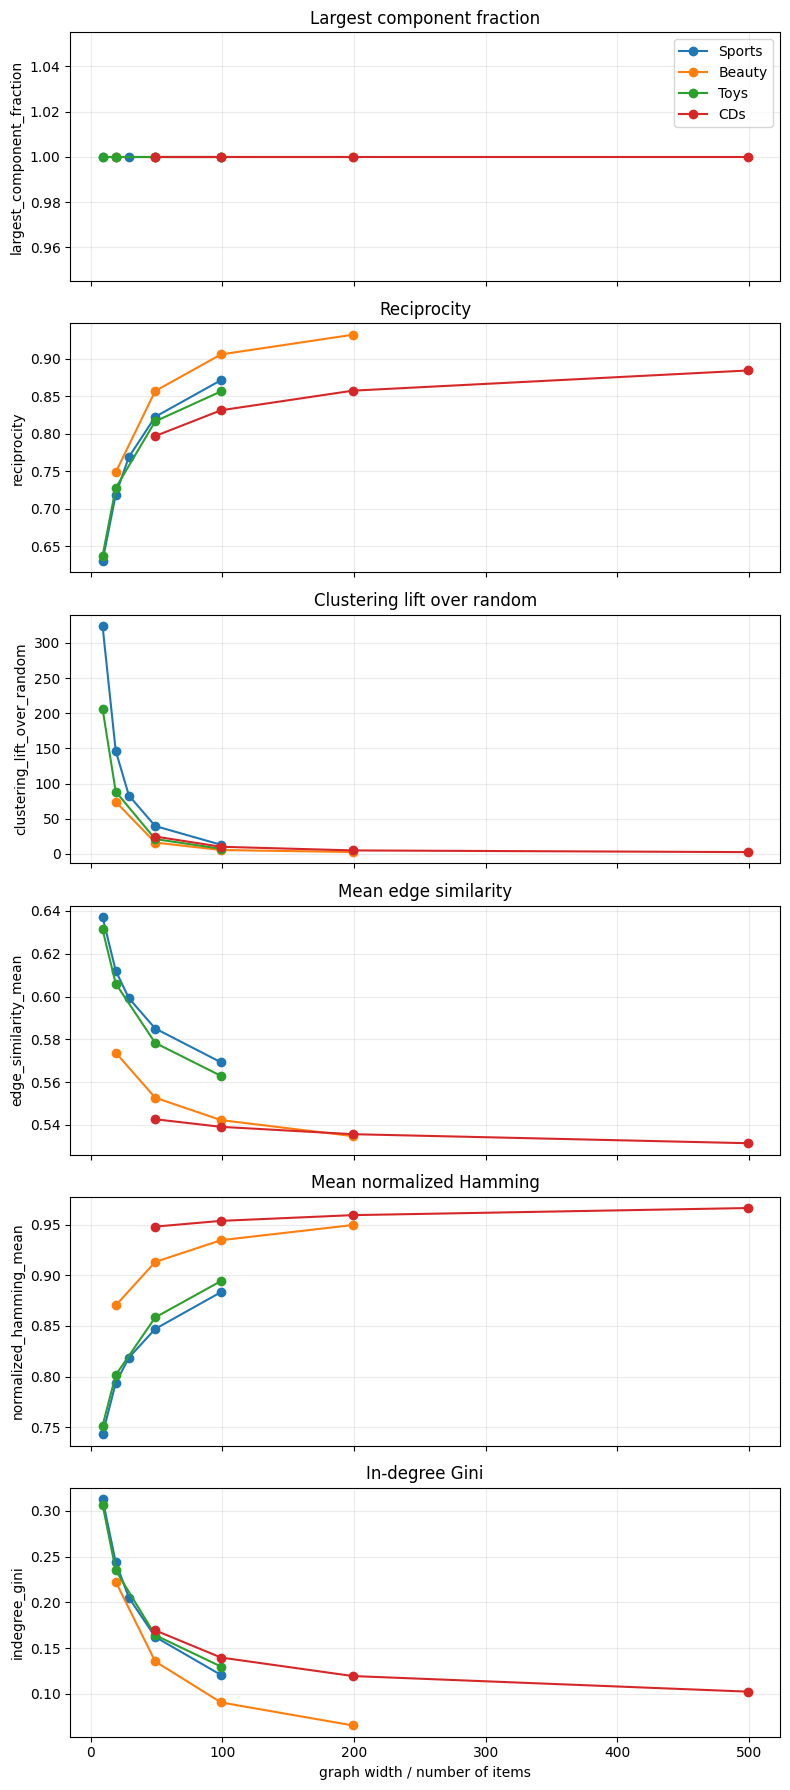

In [2]:
if static.empty:
    print('No static outputs found.')
else:
    static_at_max = (
        static.sort_values(['dataset', 'k'])
        .groupby('dataset', as_index=False)
        .tail(1)
        [[
            'dataset', 'k', 'n_items', 'n_digit',
            'largest_component_fraction', 'reciprocity',
            'clustering_lift_over_random', 'edge_similarity_mean',
            'normalized_hamming_mean', 'indegree_gini',
        ]]
        .sort_values('dataset')
    )
    display(static_at_max.round(4))

    metrics = [
        ('largest_component_fraction', 'Largest component fraction'),
        ('reciprocity', 'Reciprocity'),
        ('clustering_lift_over_random', 'Clustering lift over random'),
        ('edge_similarity_mean', 'Mean edge similarity'),
        ('normalized_hamming_mean', 'Mean normalized Hamming'),
        ('indegree_gini', 'In-degree Gini'),
    ]
    fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 3.0 * len(metrics)), sharex=True)
    for axis, (column, title) in zip(axes, metrics):
        for dataset, group in static.groupby('dataset', sort=False):
            axis.plot(group['budget_over_items'], group[column], marker='o', label=dataset)
        axis.set_title(title)
        axis.set_ylabel(column)
        axis.grid(alpha=0.25)
    axes[-1].set_xlabel('graph width / number of items')
    axes[0].legend()
    plt.tight_layout()
    plt.show()


## Dynamic B: Reachability And Saturation

These plots use real decoding traces. `reachable_rate` asks whether the held-out item was ever visited; `target_selected_rate` and Recall@10 ask whether it survived into the final recommendation list.


,dataset,n_edges,reachable_rate,target_selected_rate,recall@10,ndcg@10,mean_visited_items,final_prefix4_count_mean
8,Beauty,200,0.6827,0.0783,0.0783,0.0454,6201.8014,5960.0369
16,CDs,500,0.5095,0.0716,0.0716,0.0405,18855.9505,18741.0243
4,Sports,100,0.7798,0.0443,0.0443,0.0255,11223.9921,10602.7319
12,Toys,100,0.9612,0.0862,0.0862,0.0484,11094.8873,10427.3606


,dataset,n_edges_start,n_edges_end,reachability_gain_pp,ndcg@10_gain_pp
0,Beauty,20,200,51.52,1.48
1,CDs,50,500,35.77,1.32
2,Sports,10,100,51.49,0.34
3,Toys,10,100,56.47,0.56


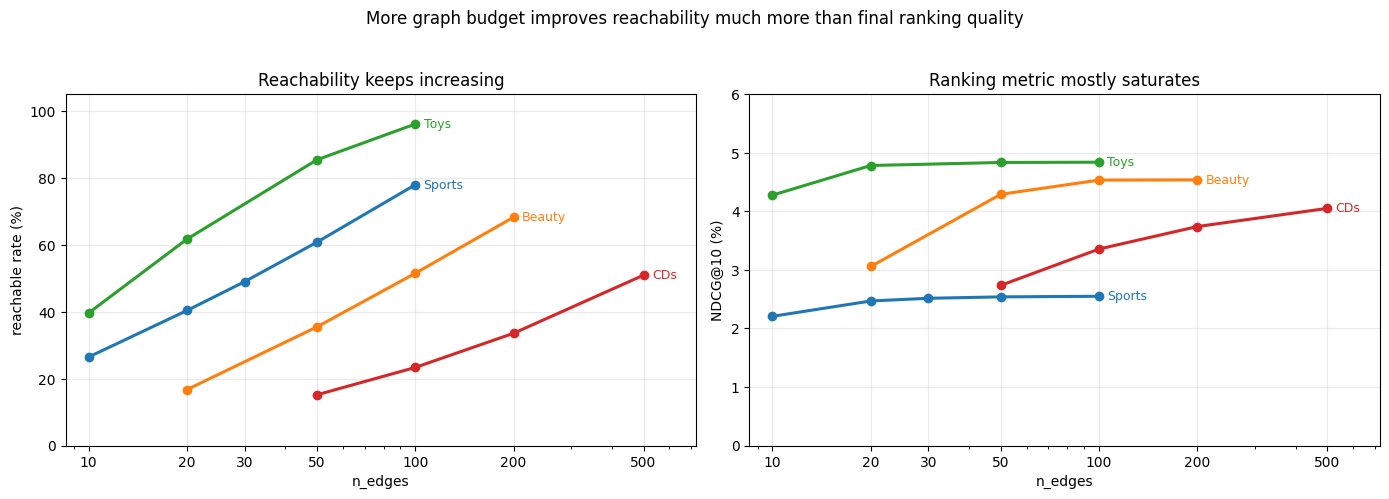

In [3]:
if dynamic.empty:
    print('No dynamic outputs found.')
else:
    dynamic_at_max = (
        dynamic.sort_values(['dataset', 'n_edges'])
        .groupby('dataset', as_index=False)
        .tail(1)
        [[
            'dataset', 'n_edges', 'reachable_rate', 'target_selected_rate',
            'recall@10', 'ndcg@10', 'mean_visited_items', 'final_prefix4_count_mean',
        ]]
        .sort_values('dataset')
    )
    display(dynamic_at_max.round(4))

    delta_rows = []
    for dataset, group in dynamic.sort_values(['dataset', 'n_edges']).groupby('dataset', sort=False):
        first = group.iloc[0]
        last = group.iloc[-1]
        delta_rows.append({
            'dataset': dataset,
            'n_edges_start': int(first['n_edges']),
            'n_edges_end': int(last['n_edges']),
            'reachability_gain_pp': 100 * (last['reachable_rate'] - first['reachable_rate']),
            'ndcg@10_gain_pp': 100 * (last['ndcg@10'] - first['ndcg@10']),
        })
    display(pd.DataFrame(delta_rows).round(2))

    all_edges = sorted(dynamic['n_edges'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    for dataset, group in dynamic.groupby('dataset', sort=False):
        group = group.sort_values('n_edges')
        reach_pct = 100 * group['reachable_rate']
        ndcg_pct = 100 * group['ndcg@10']
        line, = axes[0].plot(group['n_edges'], reach_pct, marker='o', linewidth=2.2, markersize=6)
        color = line.get_color()
        axes[1].plot(group['n_edges'], ndcg_pct, marker='o', linewidth=2.2, markersize=6, color=color)
        axes[0].annotate(dataset, (group['n_edges'].iloc[-1], reach_pct.iloc[-1]), xytext=(6, 0), textcoords='offset points', va='center', color=color, fontsize=9)
        axes[1].annotate(dataset, (group['n_edges'].iloc[-1], ndcg_pct.iloc[-1]), xytext=(6, 0), textcoords='offset points', va='center', color=color, fontsize=9)
    axes[0].set_title('Reachability keeps increasing')
    axes[0].set_ylabel('reachable rate (%)')
    axes[0].set_ylim(0, 105)
    axes[1].set_title('Ranking metric mostly saturates')
    axes[1].set_ylabel('NDCG@10 (%)')
    axes[1].set_ylim(0, max(6, 115 * dynamic['ndcg@10'].max()))
    for axis in axes:
        axis.set_xlabel('n_edges')
        axis.set_xscale('log')
        axis.set_xlim(min(all_edges) * 0.85, max(all_edges) * 1.45)
        axis.set_xticks(all_edges)
        axis.set_xticklabels([str(edge) for edge in all_edges])
        axis.grid(alpha=0.25)
    fig.suptitle('More graph budget improves reachability much more than final ranking quality', y=1.03)
    plt.tight_layout()
    plt.show()


## Frontier Memory Diagnostic

This experiment asks whether repeated frontier re-entry is simply redundant graph work or whether it plays a functional role in RPG decoding.

The answer is consistent across datasets: forcing the frontier toward new nodes increases reachability, but it destroys final Recall. Adding explicit candidate memory recovers the original Recall almost exactly. So repeated re-entry is not just waste; it acts like implicit candidate memory or stabilization. This is a diagnostic result, not a better decoder, because the memory variant visits more nodes and is not faster.


In [12]:
FRONTIER_RUN_IDS = {
    'sports': 'rpg_graph_analysis_sports_frontier_memory_full',
    'beauty': 'rpg_graph_analysis_beauty_frontier_memory_full',
    'toys_and_games': 'rpg_graph_analysis_toys_and_games_frontier_memory_full',
    'cds_and_vinyl': 'rpg_graph_analysis_cds_and_vinyl_frontier_memory_full',
}

frontier_frames = []
frontier_missing = []
for info in DATASETS:
    dataset = info['dataset']
    slug = info['slug']
    session = latest_session(slug)
    run_id = FRONTIER_RUN_IDS[slug]
    if session is None:
        frontier_missing.append({'dataset': dataset, 'reason': 'missing session'})
        continue
    summary_path = session / 'dynamic' / 'frontier_memory' / run_id / 'summaries' / 'frontier_memory_summary.csv'
    if not summary_path.is_file():
        frontier_missing.append({'dataset': dataset, 'reason': f'missing {summary_path.name}', 'path': str(summary_path)})
        continue
    frame = pd.read_csv(summary_path)
    frame.insert(0, 'dataset', dataset)
    frame.insert(1, 'slug', slug)
    frame.insert(2, 'session', session.name)
    frontier_frames.append(frame)

frontier = pd.concat(frontier_frames, ignore_index=True) if frontier_frames else pd.DataFrame()
if frontier_missing:
    print('Missing frontier-memory summaries:')
    display(pd.DataFrame(frontier_missing))

if frontier.empty:
    print('No completed frontier-memory summaries found yet.')
else:
    original = frontier[frontier['variant'] == 'original'].set_index('dataset')
    prefer = frontier[frontier['variant'] == 'prefer_unvisited'].set_index('dataset')
    memory = frontier[frontier['variant'] == 'prefer_unvisited_memory'].set_index('dataset')
    shared = [dataset for dataset in frontier['dataset'].drop_duplicates() if dataset in original.index and dataset in prefer.index and dataset in memory.index]

    frontier_table = pd.DataFrame({
        'Dataset': shared,
        'Reach original (%)': [100 * original.loc[d, 'reachable_rate'] for d in shared],
        'Reach prefer-unvisited (%)': [100 * prefer.loc[d, 'reachable_rate'] for d in shared],
        'Recall original (%)': [100 * original.loc[d, 'recall@10'] for d in shared],
        'Recall prefer-unvisited (%)': [100 * prefer.loc[d, 'recall@10'] for d in shared],
        'Recall + memory (%)': [100 * memory.loc[d, 'recall@10'] for d in shared],
        'Visited original': [original.loc[d, 'mean_visited_items'] for d in shared],
        'Visited + memory': [memory.loc[d, 'mean_visited_items'] for d in shared],
    })
    frontier_table['Reach gain (pp)'] = frontier_table['Reach prefer-unvisited (%)'] - frontier_table['Reach original (%)']
    frontier_table['Recall drop without memory (pp)'] = frontier_table['Recall original (%)'] - frontier_table['Recall prefer-unvisited (%)']
    frontier_table['Recall change with memory (pp)'] = frontier_table['Recall + memory (%)'] - frontier_table['Recall original (%)']

    paper_table = frontier_table[[
        'Dataset', 'Recall original (%)', 'Recall prefer-unvisited (%)', 'Recall + memory (%)', 'Reach gain (pp)',
    ]].rename(columns={
        'Recall original (%)': 'Orig. R@10',
        'Recall prefer-unvisited (%)': 'No re-entry R@10',
        'Recall + memory (%)': '+ memory R@10',
        'Reach gain (pp)': 'Reach gain',
    })
    display(
        paper_table.style.format({
            'Orig. R@10': '{:.2f}',
            'No re-entry R@10': '{:.2f}',
            '+ memory R@10': '{:.2f}',
            'Reach gain': '{:+.1f}',
        })
    )

    diagnostic_table = frontier_table[[
        'Dataset', 'Reach original (%)', 'Reach prefer-unvisited (%)',
        'Recall original (%)', 'Recall prefer-unvisited (%)', 'Recall + memory (%)',
        'Recall drop without memory (pp)', 'Recall change with memory (pp)',
        'Visited original', 'Visited + memory',
    ]]
    print('Optional diagnostic table, not for the main text:')
    display(
        diagnostic_table.style.format({
            'Reach original (%)': '{:.1f}',
            'Reach prefer-unvisited (%)': '{:.1f}',
            'Recall original (%)': '{:.3f}',
            'Recall prefer-unvisited (%)': '{:.3f}',
            'Recall + memory (%)': '{:.3f}',
            'Recall drop without memory (pp)': '{:.3f}',
            'Recall change with memory (pp)': '{:+.3f}',
            'Visited original': '{:,.0f}',
            'Visited + memory': '{:,.0f}',
        })
    )


,Dataset,Orig. R@10,No re-entry R@10,+ memory R@10,Reach gain
0,Sports,4.43,0.16,4.43,+15.1
1,Beauty,7.83,1.23,7.83,+3.0
2,Toys,8.62,0.17,8.62,+2.5
3,CDs,7.16,1.08,7.39,+15.4


Optional diagnostic table, not for the main text:


,Dataset,Reach original (%),Reach prefer-unvisited (%),Recall original (%),Recall prefer-unvisited (%),Recall + memory (%),Recall drop without memory (pp),Recall change with memory (pp),Visited original,Visited + memory
0,Sports,78.0,93.1,4.431,0.161,4.433,4.270,+0.002,"11,224","15,276"
1,Beauty,68.3,71.3,7.827,1.234,7.833,6.593,+0.006,"6,202","6,594"
2,Toys,96.1,98.6,8.618,0.170,8.618,8.448,+0.000,"11,095","11,590"
3,CDs,50.9,66.3,7.164,1.084,7.391,6.080,+0.226,"18,856","27,710"


The table above is the compact version to use in the main text. It keeps the important comparison in one place: reachability improves under exploratory traversal, Recall collapses without memory, and Recall returns once explicit memory is added.


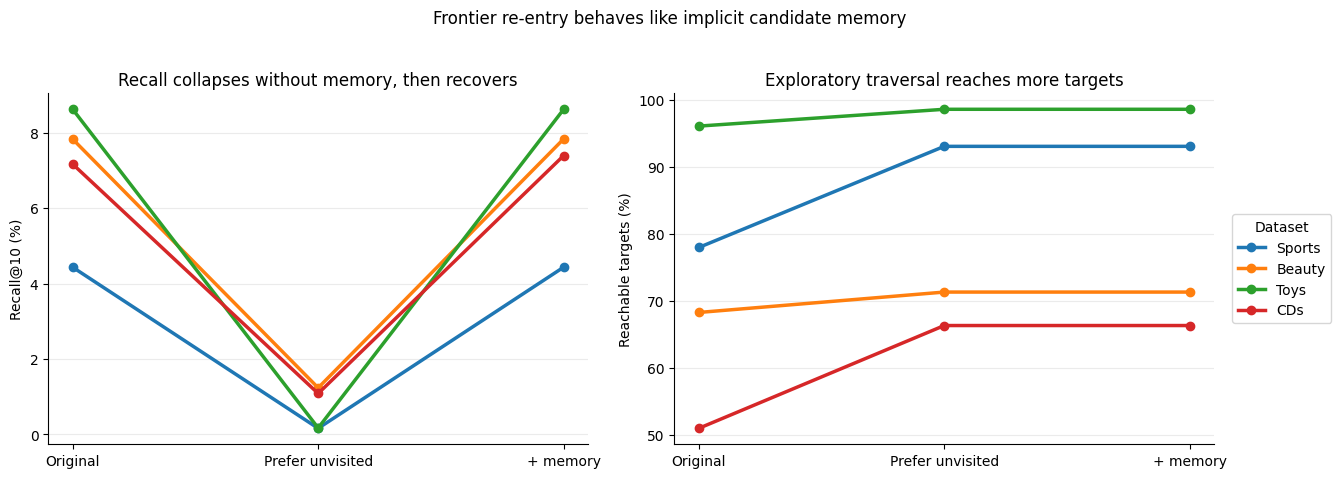

In [11]:
if not frontier.empty:
    variant_order = ['original', 'prefer_unvisited', 'prefer_unvisited_memory']
    variant_labels = ['Original', 'Prefer unvisited', '+ memory']
    colors = dict(zip(frontier['dataset'].drop_duplicates(), plt.cm.tab10.colors))

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharex=True)
    x = np.arange(len(variant_order))

    for dataset, group in frontier.groupby('dataset', sort=False):
        group = group.set_index('variant').loc[variant_order]
        color = colors[dataset]
        axes[0].plot(x, 100 * group['recall@10'], marker='o', linewidth=2.5, color=color, label=dataset)
        axes[1].plot(x, 100 * group['reachable_rate'], marker='o', linewidth=2.5, color=color, label=dataset)

    axes[0].set_title('Recall collapses without memory, then recovers')
    axes[0].set_ylabel('Recall@10 (%)')
    axes[1].set_title('Exploratory traversal reaches more targets')
    axes[1].set_ylabel('Reachable targets (%)')

    for axis in axes:
        axis.set_xticks(x)
        axis.set_xticklabels(variant_labels)
        axis.grid(axis='y', alpha=0.25)
        axis.spines[['top', 'right']].set_visible(False)
    axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title='Dataset')
    fig.suptitle('Frontier re-entry behaves like implicit candidate memory', y=1.03)
    plt.tight_layout()
    plt.show()


Conclusion for the paper: repeated re-entry in RPG is functionally important. The beam is not only an exploration frontier; it also preserves high-scoring candidates across propagation steps. Naively forcing novelty makes search coverage better but ranking much worse. A small explicit memory restores ranking quality, showing that the lost ingredient is candidate memory rather than reachability. Since the memory variant is not faster and does not improve accuracy, this should be reported as an explanatory diagnostic, not as a new decoding method.


## Experiment C: Brute-Force RPG Scoring vs Graph Decoding

This is the bottleneck check. Brute-force RPG scores every real item with the same RPG token scorer. The gap between brute-force Recall@10 and graph Recall@10 is the part attributable to graph decoding/search.


,dataset,n_edges,graph_recall@10,bf_recall@10,target_reachable_rate,target_bf_top10_graph_missed_rate,graph_top10_overlap_bf_top10_frac_mean,mean_visited_items,graph_loss_vs_bf_pp
35,Beauty,200,7.827,7.848,68.266,0.078,96.330,6201.801,0.021
67,CDs,500,7.164,7.411,50.947,0.593,80.574,18855.951,0.246
19,Sports,100,4.431,4.433,77.979,0.006,99.776,11223.992,0.002
51,Toys,100,8.618,8.618,96.123,0.000,99.973,11094.887,0.000


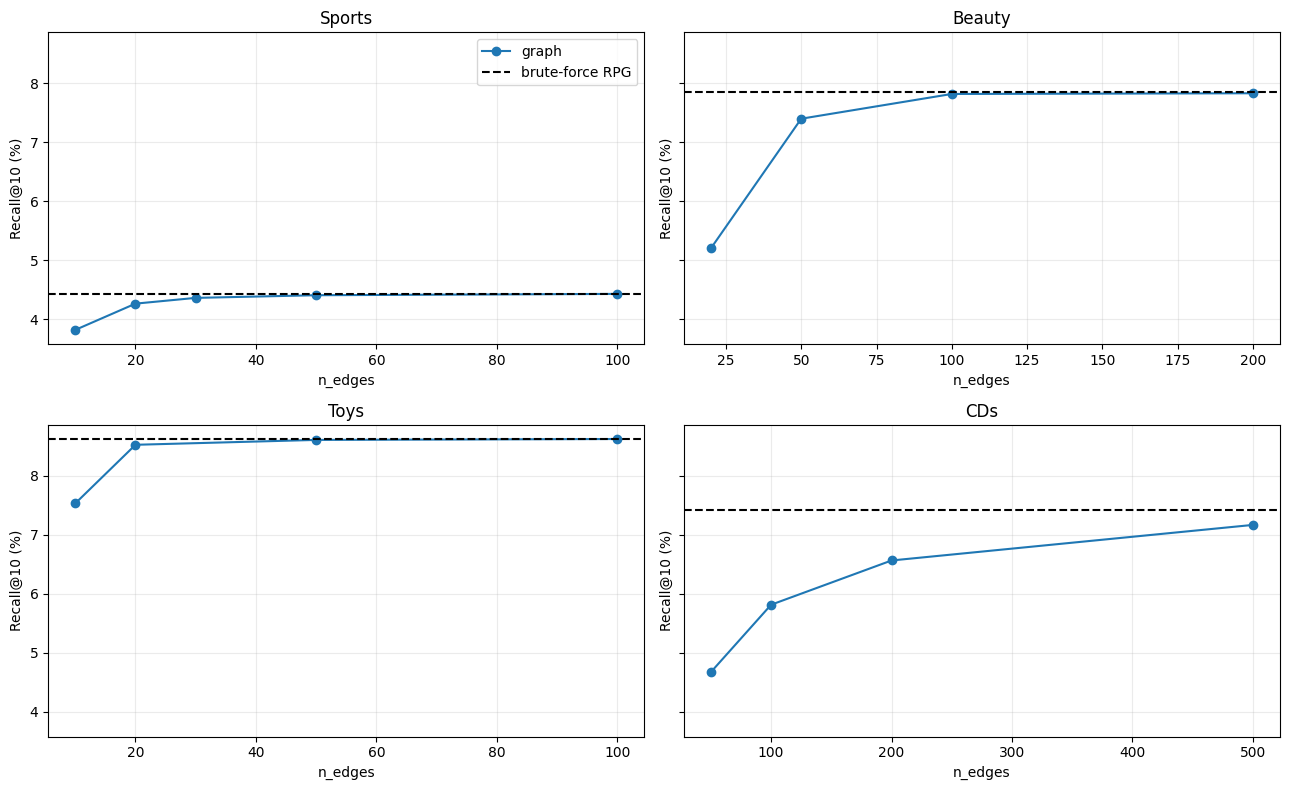

In [6]:
if scoring.empty or bf.empty:
    print('Scoring outputs are incomplete.')
else:
    mean_scoring = scoring[scoring['aggregate'] == 'mean_across_seeds'].copy()
    scoring_at_max = (
        mean_scoring.sort_values(['dataset', 'n_edges'])
        .groupby('dataset', as_index=False)
        .tail(1)
        [[
            'dataset', 'n_edges', 'graph_recall@10', 'bf_recall@10',
            'target_reachable_rate', 'target_bf_top10_graph_missed_rate',
            'graph_top10_overlap_bf_top10_frac_mean', 'mean_visited_items',
        ]]
        .sort_values('dataset')
    )
    scoring_at_max['graph_loss_vs_bf_pp'] = 100 * (scoring_at_max['bf_recall@10'] - scoring_at_max['graph_recall@10'])
    for col in ['graph_recall@10', 'bf_recall@10', 'target_reachable_rate', 'target_bf_top10_graph_missed_rate', 'graph_top10_overlap_bf_top10_frac_mean']:
        scoring_at_max[col] = 100 * scoring_at_max[col]
    display(scoring_at_max.round(3))

    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
    axes = axes.ravel()
    for axis, (dataset, group) in zip(axes, mean_scoring.groupby('dataset', sort=False)):
        bf_value = float(group['bf_recall@10'].iloc[0])
        axis.plot(group['n_edges'], 100 * group['graph_recall@10'], marker='o', label='graph')
        axis.axhline(100 * bf_value, color='black', linestyle='--', label='brute-force RPG')
        axis.set_title(dataset)
        axis.set_xlabel('n_edges')
        axis.set_ylabel('Recall@10 (%)')
        axis.grid(alpha=0.25)
    axes[0].legend()
    plt.tight_layout()
    plt.show()


## No-Trace Perf: Runtime And Memory

This uses the separate `perf_inference` benchmark, not traced Experiment C timing. It compares vectorized all-item scoring against upstream graph generation under each dataset's graph-analysis hparams.


,dataset,method_label,n_edges,n_users,n_items,ms_per_user_median,users_per_second_median,peak_cuda_runtime_delta_allocated_gb_median,recall@10_median,ndcg@10_median,slowdown_vs_bruteforce
0,Sports,brute-force RPG scoring,NaN,35598,18358,0.2508,3986.7985,0.1412,0.0443,0.0255,1.0000
1,Sports,upstream graph generate,10.0,35598,18358,1.6577,603.2425,0.1032,0.0381,0.0221,6.6089
2,Sports,upstream graph generate,30.0,35598,18358,2.6191,381.8136,0.1028,0.0437,0.0252,10.4417
3,Sports,upstream graph generate,100.0,35598,18358,4.3122,231.9001,0.1025,0.0443,0.0255,17.1919
4,Beauty,brute-force RPG scoring,NaN,22363,12102,0.3124,3200.9060,0.1887,0.0785,0.0456,1.0000
5,Beauty,upstream graph generate,20.0,22363,12102,1.0654,938.5815,0.1901,0.0523,0.0306,3.4104
6,Beauty,upstream graph generate,100.0,22363,12102,1.4858,673.0521,0.1887,0.0782,0.0453,4.7558
7,Beauty,upstream graph generate,200.0,22363,12102,2.1967,455.2248,0.1879,0.0783,0.0454,7.0315
8,Toys,brute-force RPG scoring,NaN,19412,11925,0.2457,4070.0919,0.1028,0.0862,0.0483,1.0000
9,Toys,upstream graph generate,10.0,19412,11925,1.4240,702.2294,0.1028,0.0751,0.0427,5.7960


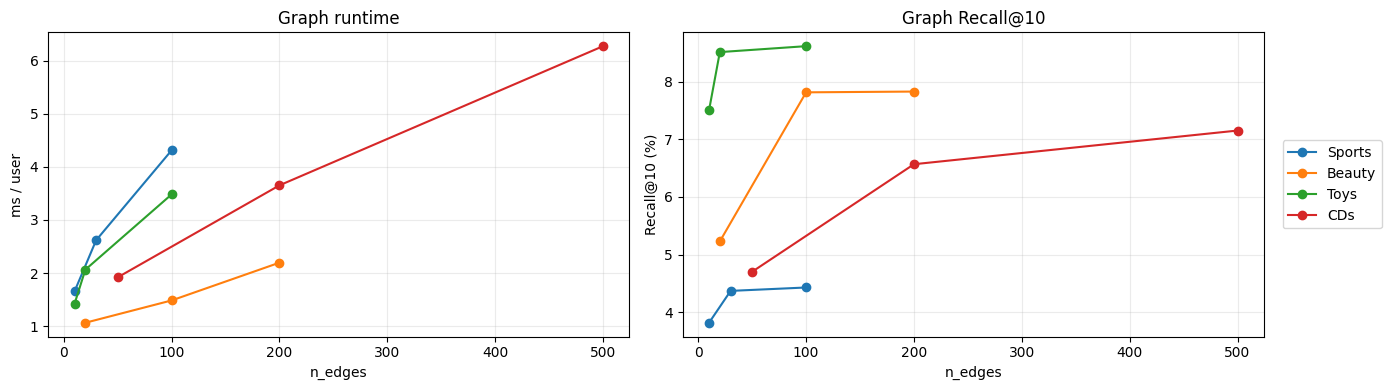

In [7]:
if perf.empty:
    print('No perf outputs found.')
else:
    perf_table = perf.copy()
    perf_table['method_label'] = perf_table['method'].replace({
        'bruteforce_all_items': 'brute-force RPG scoring',
        'graph_generate': 'upstream graph generate',
    })
    brute_ms = (
        perf_table[perf_table['method'] == 'bruteforce_all_items']
        .set_index('dataset')['ms_per_user_median']
    )
    perf_table['slowdown_vs_bruteforce'] = perf_table.apply(
        lambda row: row['ms_per_user_median'] / brute_ms.loc[row['dataset']],
        axis=1,
    )
    display(perf_table[[
        'dataset', 'method_label', 'n_edges', 'n_users', 'n_items',
        'ms_per_user_median', 'users_per_second_median',
        'peak_cuda_runtime_delta_allocated_gb_median',
        'recall@10_median', 'ndcg@10_median', 'slowdown_vs_bruteforce',
    ]].round(4))

    graph_perf = perf_table[perf_table['method'] == 'graph_generate'].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for dataset, group in graph_perf.groupby('dataset', sort=False):
        axes[0].plot(group['n_edges'], group['ms_per_user_median'], marker='o', label=dataset)
        axes[1].plot(group['n_edges'], 100 * group['recall@10_median'], marker='o', label=dataset)
    axes[0].set_title('Graph runtime')
    axes[0].set_ylabel('ms / user')
    axes[1].set_title('Graph Recall@10')
    axes[1].set_ylabel('Recall@10 (%)')
    for axis in axes:
        axis.set_xlabel('n_edges')
        axis.grid(alpha=0.25)
    axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()


## Compact Takeaways Template

Use this notebook to identify cross-dataset patterns, then write final prose in the report. The main quantities to compare are:

- Static: whether all datasets are connected, clustered, and semantically non-random.
- Dynamic: whether target reachability grows faster than final Recall@10.
- Scoring C: whether graph decoding approaches the brute-force RPG scoring upper bound.
- Perf: whether graph generation is faster/slower than vectorized brute-force scoring under these graph-analysis hparams.
